# FOMC ETF IV Pipeline — Full Coverage 2010–2026

Reconstructs Treasury ETF implied volatility across all FOMC meetings using
three public data sources — no Bloomberg required:

| Period | IV Source | ETF Proxy |
|---|---|---|
| 2010–2020 | CBOE VXTYN (via FRED) | vrp_panel.parquet bridge |
| 2020–2026 | ICE BofA MOVE Index (Yahoo `^MOVE`) | duration-weighted yield→price vol |
| Any date | AlphaVantage / WRDS options | direct ATM IV (if key set) |

**Gap = RV − IV** (positive = realized > implied = historical buy-vol edge).
**GapSpread = Gap(SHY) − Gap(TLT)** (positive = front-end exceeded long-end more).

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")
try:
    get_ipython().run_line_magic("matplotlib", "inline")   # noqa: F821
except (NameError, AttributeError):
    import matplotlib; matplotlib.use("Agg")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# Pipeline functions
from fomc_etf_iv_pipeline import (
    load_fomc_dates, build_fred_panel, build_realized_curve, build_implied_curve,
    add_iv_percentile, merge_gap_curve, add_gap_spread, add_proxy_basis_flag,
    print_coverage_table, fetch_etf_ohlc, ETF_MAP,
    _ETF_DURATION, _VXTYN_END, _MOVE_YIELD_RATIO,
)

VIZ_DIR = Path("fomc_viz")
VIZ_DIR.mkdir(exist_ok=True)

COLORS = {
    "SHY": "#1f77b4",  # 2Y — blue
    "IEI": "#2ca02c",  # 5Y — green
    "IEF": "#ff7f0e",  # 10Y — orange
    "TLH": "#9467bd",  # 20Y — purple
    "TLT": "#d62728",  # 30Y — red
}
ETF_LABELS = {
    "SHY": "SHY (2Y)",
    "IEI": "IEI (5Y)",
    "IEF": "IEF (10Y)",
    "TLH": "TLH (20Y)",
    "TLT": "TLT (30Y)",
}

print("Imports OK")

Imports OK


## Layer 1 — FRED: Yields, Curve, and VXTYN Bridge

In [2]:
fred_panel = build_fred_panel(start="2010-01-01")

# Show key series
cols_show = [c for c in ["yield_2y","yield_10y","yield_30y","spread_2s10s","vxtyn"]
             if c in fred_panel.columns]
print(f"FRED panel: {len(fred_panel)} daily rows  cols={list(fred_panel.columns)}")
print(f"\nLatest values ({fred_panel.index[-1].date()}):")
print(fred_panel[cols_show].iloc[-1].to_string())
print(f"\nVXTYN coverage: {fred_panel['vxtyn'].first_valid_index().date()} → "
      f"{fred_panel['vxtyn'].last_valid_index().date()} (discontinued {_VXTYN_END.date()})")


[FRED] Fetching yield / curve-feature / VXTYN series ...
  DGS2       → yield_2y       12510 obs  [1976-06-01 – 2026-06-22]
  DGS5       → yield_5y       16102 obs  [1962-01-02 – 2026-06-22]
  DGS7       → yield_7y       14232 obs  [1969-07-01 – 2026-06-22]
  DGS10      → yield_10y      16102 obs  [1962-01-02 – 2026-06-22]
  DGS20      → yield_20y      14413 obs  [1962-01-02 – 2026-06-22]
  DGS30      → yield_30y      12332 obs  [1977-02-15 – 2026-06-22]
  T10Y2Y     → curve_10y2y    12511 obs  [1976-06-01 – 2026-06-23]
  T10Y3M     → curve_10y3m    11120 obs  [1982-01-04 – 2026-06-23]
  [FRED] VXTYN: refreshing cache (last=2020-05-15)


  VXTYN      → vxtyn          4363 obs  [2003-01-02 – 2020-05-15]
[FRED] Panel: (16821, 9), VXTYN available through 2020-05-15 (discontinued; pre-2020 cross-check only)
FRED panel: 16821 daily rows  cols=['yield_2y', 'yield_5y', 'yield_7y', 'yield_10y', 'yield_20y', 'yield_30y', 'curve_10y2y', 'curve_10y3m', 'vxtyn']

Latest values (2026-06-23):
yield_2y     4.24
yield_10y    4.51
yield_30y    4.95
vxtyn         NaN

VXTYN coverage: 2003-01-02 → 2020-05-15 (discontinued 2020-05-15)


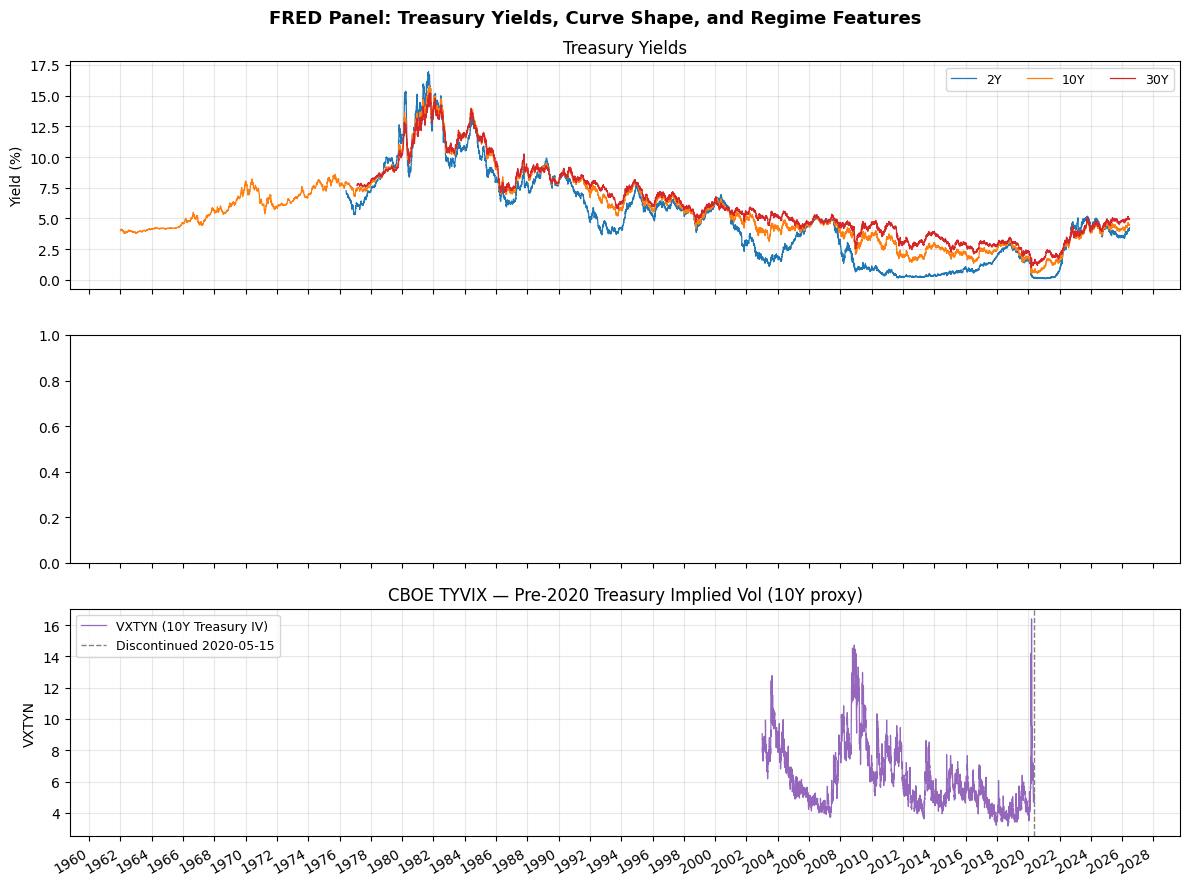

Fig 1 saved


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle("FRED Panel: Treasury Yields, Curve Shape, and Regime Features",
             fontsize=13, fontweight="bold")

# Panel 1: Yield curve levels
ax = axes[0]
for col, lbl, clr in [("yield_2y","2Y","#1f77b4"),("yield_10y","10Y","#ff7f0e"),
                       ("yield_30y","30Y","#d62728")]:
    if col in fred_panel.columns:
        ax.plot(fred_panel.index, fred_panel[col], label=lbl, color=clr, lw=0.9)
ax.set_ylabel("Yield (%)")
ax.set_title("Treasury Yields")
ax.legend(ncol=3, fontsize=9)
ax.grid(alpha=0.3)

# Panel 2: 2s10s spread
ax = axes[1]
if "spread_2s10s" in fred_panel.columns:
    spread = fred_panel["spread_2s10s"]
    ax.fill_between(fred_panel.index, spread, 0,
                    where=spread >= 0, color="#2ca02c", alpha=0.3, label="Normal (10Y>2Y)")
    ax.fill_between(fred_panel.index, spread, 0,
                    where=spread < 0,  color="#d62728", alpha=0.3, label="Inverted")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("bps")
    ax.set_title("2s10s Spread")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Panel 3: VXTYN (pre-2020 implied vol)
ax = axes[2]
if "vxtyn" in fred_panel.columns:
    vxtyn = fred_panel["vxtyn"].dropna()
    ax.plot(vxtyn.index, vxtyn, color="#9467bd", lw=0.9, label="VXTYN (10Y Treasury IV)")
    ax.axvline(_VXTYN_END, color="gray", ls="--", lw=1, label=f"Discontinued {_VXTYN_END.date()}")
    ax.set_ylabel("VXTYN")
    ax.set_title("CBOE TYVIX — Pre-2020 Treasury Implied Vol (10Y proxy)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(VIZ_DIR / "fig_etf_01_fred_panel.png", dpi=130, bbox_inches="tight")
plt.show()
print("Fig 1 saved")

## Layer 2 — ETF Realized Volatility (GK Estimator)

In [4]:
fomc_dates = load_fomc_dates()
ohlc_cache = {t: fetch_etf_ohlc(t) for t in ETF_MAP}

print("ETF OHLC cache loaded:")
for t, df in ohlc_cache.items():
    print(f"  {ETF_LABELS[t]}: {len(df)} rows  "
          f"{df.index.min().date()} → {df.index.max().date()}")

[calendar] 133 FOMC meetings from fomc_features.parquet
ETF OHLC cache loaded:
  SHY (2Y): 5653 rows  2004-01-02 → 2026-06-23
  IEI (5Y): 4892 rows  2007-01-11 → 2026-06-23
  IEF (10Y): 5653 rows  2004-01-02 → 2026-06-23
  TLH (20Y): 4892 rows  2007-01-11 → 2026-06-23
  TLT (30Y): 5653 rows  2004-01-02 → 2026-06-23


In [5]:
realized = build_realized_curve(fomc_dates, ohlc_cache=ohlc_cache)
print(f"\nRealized curve: {len(realized)} rows, {realized['rv_event_var'].notna().sum()} with GK RV")
realized["rv_vol_pct"] = np.sqrt(realized["rv_event_var"].clip(lower=0)) * 100
print(realized.groupby("etf")["rv_vol_pct"].describe().round(3).to_string())


[Layer 2] ETF realized vol: ['SHY', 'IEI', 'IEF', 'TLH', 'TLT'] × 133 meetings
  SHY: 5653 OHLC rows
  IEI: 4892 OHLC rows
  IEF: 5653 OHLC rows
  TLH: 4892 OHLC rows
  TLT: 5653 OHLC rows


[Layer 2] Realized curve: 665 rows, 665 with event-day GK RV

Realized curve: 665 rows, 665 with GK RV
     count    mean    std    min    25%    50%     75%     max
etf                                                           
IEF  133.0   6.372  5.038  2.011  3.834  5.224   6.815  41.356
IEI  133.0   3.932  2.407  0.814  2.419  3.353   4.782  15.110
SHY  133.0   1.384  0.957  0.062  0.641  1.160   1.915   4.340
TLH  133.0   8.527  5.866  2.160  4.504  6.568   9.929  35.267
TLT  133.0  12.154  8.586  3.782  7.618  9.534  13.708  66.876


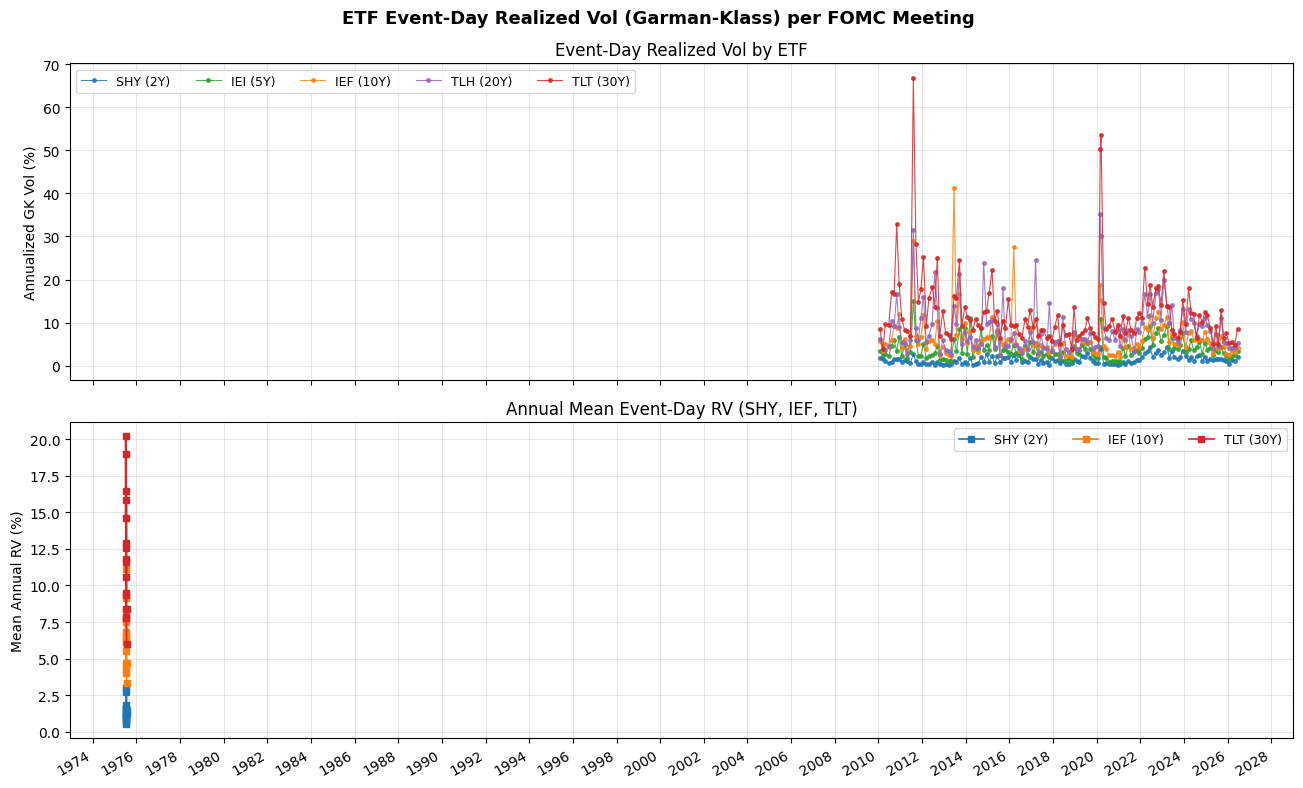

Fig 2 saved


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle("ETF Event-Day Realized Vol (Garman-Klass) per FOMC Meeting",
             fontsize=13, fontweight="bold")

# Panel 1: GK event-day vol time series per ETF
ax = axes[0]
for etf in ETF_MAP:
    sub = realized[realized["etf"] == etf].sort_values("meeting_date")
    rv_pct = np.sqrt(sub["rv_event_var"].clip(lower=0)) * 100
    ax.plot(sub["meeting_date"], rv_pct,
            color=COLORS[etf], label=ETF_LABELS[etf],
            marker="o", ms=2.5, lw=0.8, alpha=0.85)

ax.set_ylabel("Annualized GK Vol (%)")
ax.set_title("Event-Day Realized Vol by ETF")
ax.legend(ncol=5, fontsize=9)
ax.grid(alpha=0.3)

# Panel 2: Cross-sectional boxplot per year
ax = axes[1]
realized["year"] = pd.DatetimeIndex(realized["meeting_date"]).year
realized["rv_vol_pct"] = np.sqrt(realized["rv_event_var"].clip(lower=0)) * 100

for etf in ["SHY", "IEF", "TLT"]:
    sub = realized[realized["etf"] == etf].dropna(subset=["rv_vol_pct"])
    yr_means = sub.groupby("year")["rv_vol_pct"].mean()
    ax.plot(yr_means.index, yr_means.values,
            color=COLORS[etf], label=ETF_LABELS[etf],
            marker="s", ms=4, lw=1.2)

ax.set_ylabel("Mean Annual RV (%)")
ax.set_title("Annual Mean Event-Day RV (SHY, IEF, TLT)")
ax.legend(ncol=3, fontsize=9)
ax.grid(alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(VIZ_DIR / "fig_etf_02_realized_vol.png", dpi=130, bbox_inches="tight")
plt.show()
print("Fig 2 saved")

## Layer 3 — ETF Implied Volatility

Two public bridges cover the full 2010–2026 window:

### Bridge A: VXTYN (2010–2020)
CBOE TYVIX was stripped into per-tenor event IVs and stored in `vrp_panel.parquet`.
Mapping: 2Y→SHY, 5Y→IEI, 10Y→IEF, 20Y→TLH, 30Y→TLT.

### Bridge B: ICE BofA MOVE Index (2020–2026)
MOVE (`^MOVE`, Yahoo Finance) is a 30-day blended Treasury yield-vol index.
Conversion formula (calibrated on VXTYN 2010–2020):

```
yield_vol_bps(tenor) = MOVE × ratio[tenor]       # ratios: 2Y=1.57, 10Y=1.73, 30Y=1.54
price_vol_pct(ETF)   = yield_vol_bps × duration  / 100
iv_event_var         = (price_vol_pct / 100)²
```

Higher-priority sources (WRDS, AlphaVantage, manual CSV) override these bridges.

In [7]:
# Show MOVE Index history
import yfinance as yf
move_raw = yf.download("^MOVE", start="2010-01-01", end=pd.Timestamp.today().strftime("%Y-%m-%d"),
                        progress=False)
move = move_raw[("Close", "^MOVE")].squeeze()

print(f"^MOVE index: {len(move)} daily rows  {move.index.min().date()} → {move.index.max().date()}")
print(f"Range: {move.min():.0f} – {move.max():.0f} bps  |  Current: {move.iloc[-1]:.1f} bps")
print("\nMOVE → ETF price-vol conversion (example at current MOVE):")
cur_move = float(move.iloc[-1])
for tenor, etf in [("2Y","SHY"),("10Y","IEF"),("30Y","TLT")]:
    ybps = cur_move * _MOVE_YIELD_RATIO[tenor]
    pvol = ybps * _ETF_DURATION[etf] / 100
    print(f"  {ETF_LABELS[etf]}: yield_bps={ybps:.1f}  →  price_vol={pvol:.2f}%")

^MOVE index: 4057 daily rows  2010-01-04 → 2026-06-18
Range: 37 – 183 bps  |  Current: 65.4 bps

MOVE → ETF price-vol conversion (example at current MOVE):
  SHY (2Y): yield_bps=102.5  →  price_vol=1.95%
  IEF (10Y): yield_bps=113.3  →  price_vol=8.50%
  TLT (30Y): yield_bps=100.8  →  price_vol=16.13%


In [8]:
# Build the implied curve — uses VXTYN bridge (2010-2020) + MOVE bridge (2020-2026)
implied = build_implied_curve(fomc_dates, ohlc_cache=ohlc_cache, use_vxtyn_bridge=True)
implied = add_iv_percentile(implied)

print(f"\nImplied curve: {len(implied)} rows  |  "
      f"{implied['iv_event_var'].notna().sum()} with IV")
print("\nSource breakdown:")
print(implied["source"].value_counts().to_string())
print("\nIV vol% summary by ETF:")
print(implied.groupby("etf")["iv_event_vol_pct"].describe().round(3).to_string())

[manual CSV] 0 rows from etf_implied_manual.csv
  [VXTYN bridge] 420 rows (2010-01-27 → 2020-04-29) across 5 ETFs
  [MOVE bridge] 245 rows (2020-06-10 → 2026-06-17) MOVE range ≈ 37–183 bps

[Layer 3] ETF implied vol: ['SHY', 'IEI', 'IEF', 'TLH', 'TLT'] × 133 meetings
  INFO: WRDS_USERNAME not set — OptionMetrics source disabled.
[Layer 3] Implied curve: 665 rows  665 with IV  (cached=0, new API calls=0)
  Source breakdown:
    vxtyn_bridge                    420
    move_bridge                     245

Implied curve: 665 rows  |  665 with IV

Source breakdown:
source
vxtyn_bridge    420
move_bridge     245

IV vol% summary by ETF:


     count    mean    std    min     25%     50%     75%     max
etf                                                             
IEF  133.0  10.308  4.832  2.324   6.080   9.849  12.964  23.729
IEI  133.0   6.254  2.932  1.410   3.689   5.975   7.865  14.396
SHY  133.0   2.364  1.108  0.533   1.394   2.258   2.972   5.441
TLH  133.0  14.937  7.002  3.367   8.810  14.271  18.785  34.385
TLT  133.0  19.566  9.172  4.411  11.540  18.693  24.607  45.040


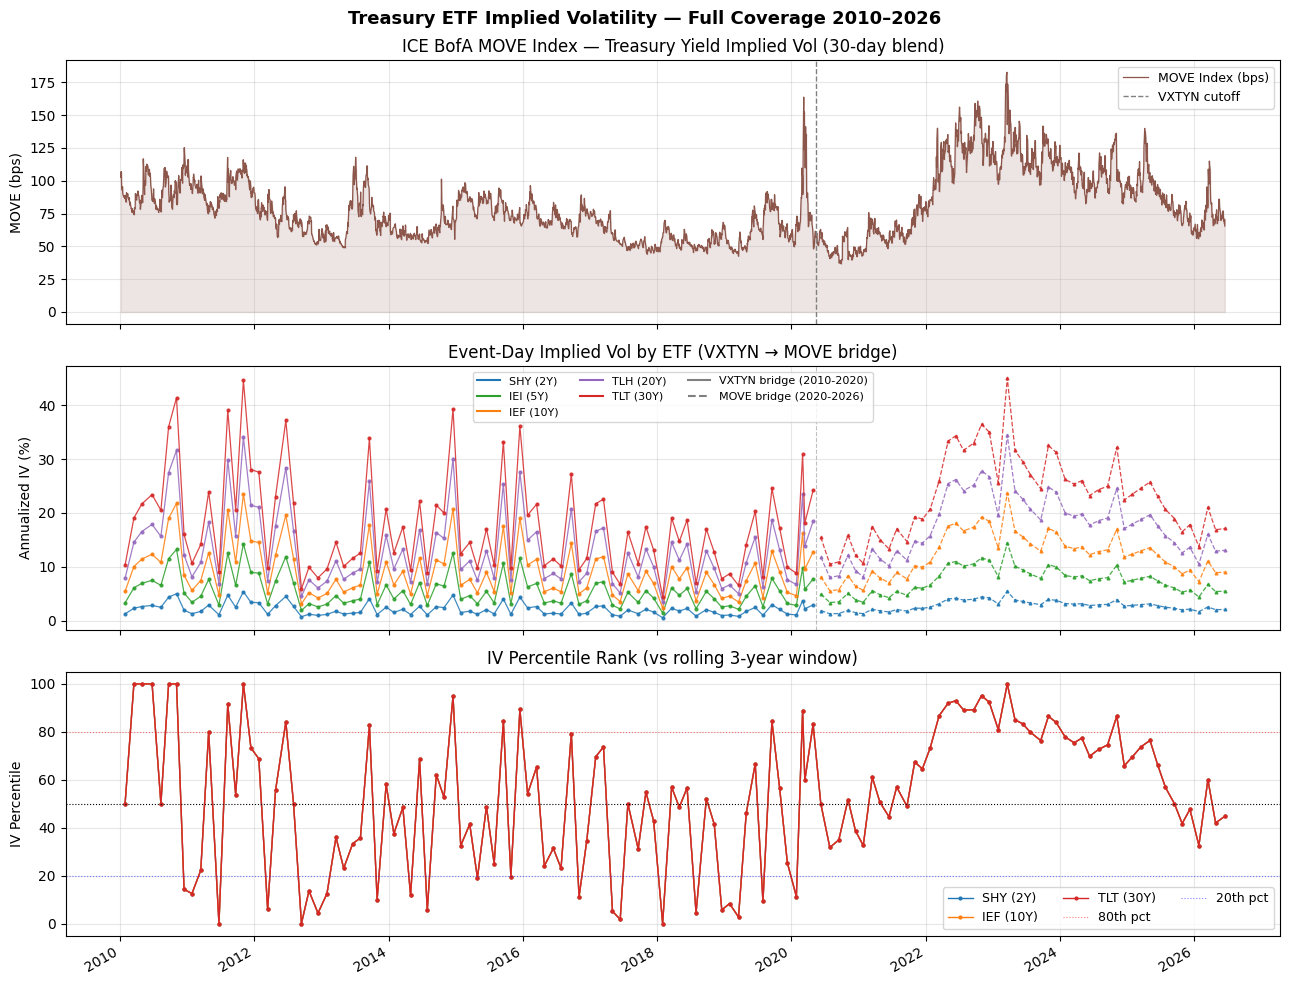

Fig 3 saved


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.suptitle("Treasury ETF Implied Volatility — Full Coverage 2010–2026",
             fontsize=13, fontweight="bold")

# Panel 1: MOVE index
ax = axes[0]
ax.plot(move.index, move.values, color="#8c564b", lw=0.9, label="MOVE Index (bps)")
ax.axvline(_VXTYN_END, color="gray", ls="--", lw=1, label=f"VXTYN cutoff")
ax.fill_between(move.index, move.values, alpha=0.15, color="#8c564b")
ax.set_ylabel("MOVE (bps)")
ax.set_title("ICE BofA MOVE Index — Treasury Yield Implied Vol (30-day blend)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 2: Per-ETF IV vol% at each FOMC meeting
ax = axes[1]
for etf in ETF_MAP:
    sub = implied[implied["etf"] == etf].sort_values("meeting_date")
    mask = sub["iv_event_vol_pct"].notna()
    # Different linestyle for bridge sources
    vx_sub  = sub[mask & (sub["source"] == "vxtyn_bridge")]
    mv_sub  = sub[mask & (sub["source"] == "move_bridge")]
    if not vx_sub.empty:
        ax.plot(vx_sub["meeting_date"], vx_sub["iv_event_vol_pct"],
                color=COLORS[etf], lw=0.9, alpha=0.85, marker="o", ms=2)
    if not mv_sub.empty:
        ax.plot(mv_sub["meeting_date"], mv_sub["iv_event_vol_pct"],
                color=COLORS[etf], lw=0.9, alpha=0.85, ls="--", marker="^", ms=2,
                label=ETF_LABELS[etf] if vx_sub.empty else None)

# Legend and source annotation
from matplotlib.lines import Line2D
legend_handles = [Line2D([0],[0], color=COLORS[e], lw=1.5, label=ETF_LABELS[e])
                  for e in ETF_MAP]
legend_handles += [Line2D([0],[0], color="gray", lw=1.5, ls="-",  label="VXTYN bridge (2010-2020)"),
                   Line2D([0],[0], color="gray", lw=1.5, ls="--", label="MOVE bridge (2020-2026)")]
ax.legend(handles=legend_handles, ncol=3, fontsize=8)
ax.axvline(_VXTYN_END, color="gray", ls="--", lw=0.8, alpha=0.5)
ax.set_ylabel("Annualized IV (%)")
ax.set_title("Event-Day Implied Vol by ETF (VXTYN → MOVE bridge)")
ax.grid(alpha=0.3)

# Panel 3: IV percentile (how rich/cheap is current IV vs history)
ax = axes[2]
for etf in ["SHY", "IEF", "TLT"]:
    sub = implied[(implied["etf"] == etf) & implied["iv_percentile"].notna()]
    ax.plot(sub["meeting_date"], sub["iv_percentile"],
            color=COLORS[etf], label=ETF_LABELS[etf], lw=1, marker="o", ms=2)
ax.axhline(50, color="black", ls=":", lw=0.8)
ax.axhline(80, color="red",   ls=":", lw=0.8, alpha=0.5, label="80th pct")
ax.axhline(20, color="blue",  ls=":", lw=0.8, alpha=0.5, label="20th pct")
ax.set_ylabel("IV Percentile")
ax.set_title("IV Percentile Rank (vs rolling 3-year window)")
ax.legend(ncol=3, fontsize=9)
ax.set_ylim(-5, 105)
ax.grid(alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(VIZ_DIR / "fig_etf_03_implied_vol.png", dpi=130, bbox_inches="tight")
plt.show()
print("Fig 3 saved")

## Layer 4 — Gap and GapSpread

In [10]:
gap_df = merge_gap_curve(realized, implied)
gap_df = add_gap_spread(gap_df)
gap_df = add_proxy_basis_flag(gap_df)

print_coverage_table(gap_df)

print("\nGap statistics (RV − IV) by ETF:")
gap_stats = (gap_df.dropna(subset=["gap"])
             .groupby("etf")["gap"]
             .agg(["count","mean","std","min","max"])
             .round(6))
gap_stats["mean_pct"] = (np.sqrt(gap_stats["mean"].clip(lower=0)) * 100).round(3)
print(gap_stats.to_string())


[Layer 4] GapSpread_proxy: 133/133 meetings have both legs

════════════════════════════════════════════════════════════════════════
  COVERAGE TABLE — meetings with usable RV, IV, and gap (per ETF per year)
════════════════════════════════════════════════════════════════════════
  Year |   IEF   |   IEI   |   SHY   |   TLH   |   TLT   | Total
  --------------------------------------------------------------
  2010 |   8/8   |   8/8   |   8/8   |   8/8   |   8/8   |   40/8
  2011 |   8/8   |   8/8   |   8/8   |   8/8   |   8/8   |   40/8
  2012 |   8/8   |   8/8   |   8/8   |   8/8   |   8/8   |   40/8
  2013 |   8/8   |   8/8   |   8/8   |   8/8   |   8/8   |   40/8
  2014 |   8/8   |   8/8   |   8/8   |   8/8   |   8/8   |   40/8
  2015 |   8/8   |   8/8   |   8/8   |   8/8   |   8/8   |   40/8
  2016 |   8/8   |   8/8   |   8/8   |   8/8   |   8/8   |   40/8
  2017 |   8/8   |   8/8   |   8/8   |   8/8   |   8/8   |   40/8
  2018 |   8/8   |   8/8   |   8/8   |   8/8   |   8/8   |  

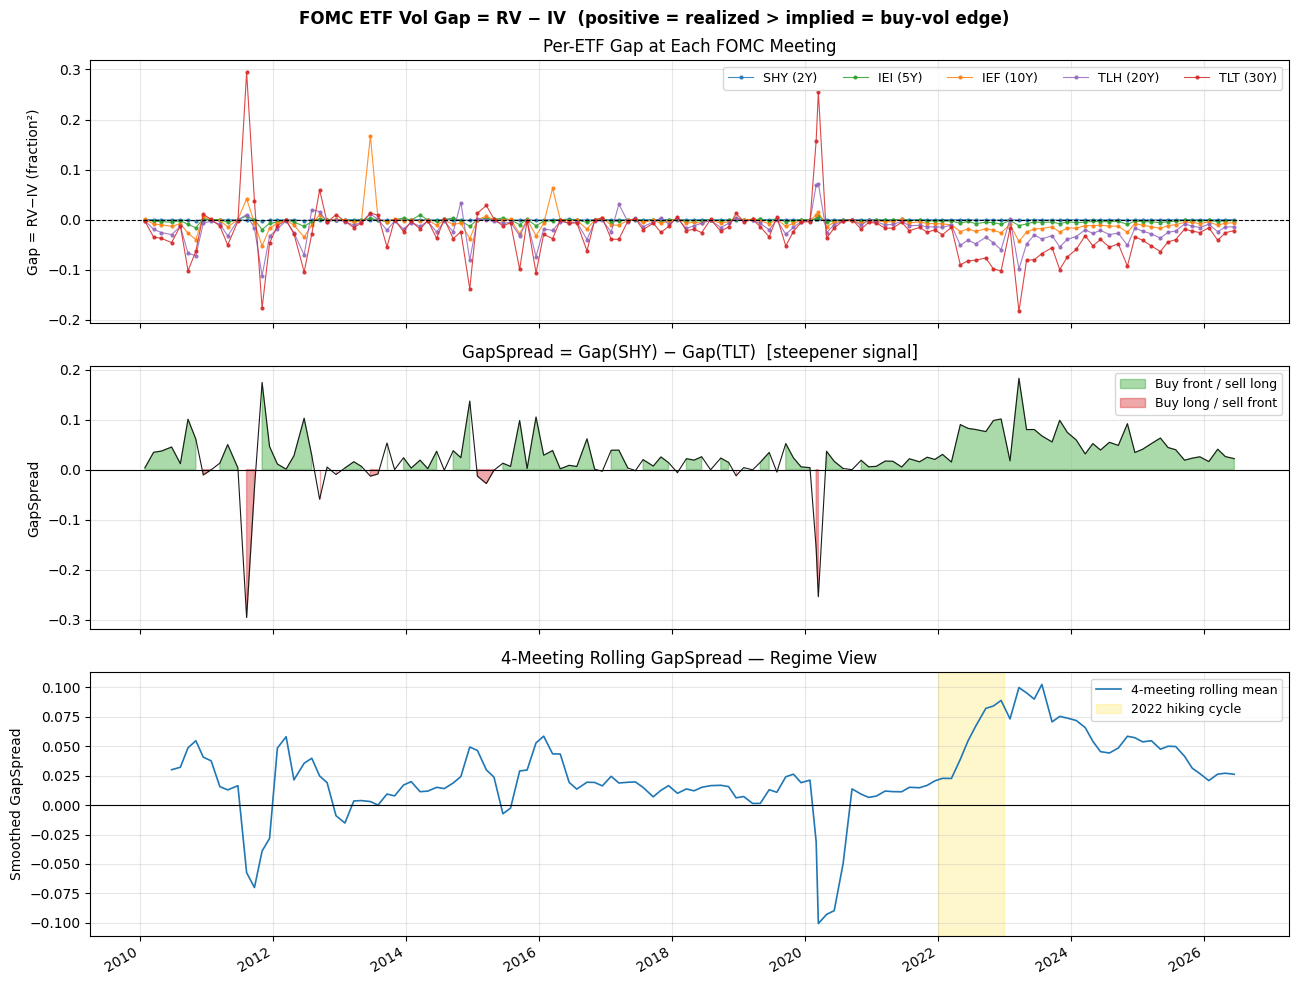

Fig 4 saved


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.suptitle("FOMC ETF Vol Gap = RV − IV  (positive = realized > implied = buy-vol edge)",
             fontsize=12, fontweight="bold")

# Panel 1: Gap per ETF
ax = axes[0]
for etf in ETF_MAP:
    sub = gap_df[(gap_df["etf"] == etf) & gap_df["gap"].notna()].sort_values("meeting_date")
    ax.plot(sub["meeting_date"], sub["gap"],
            color=COLORS[etf], label=ETF_LABELS[etf], lw=0.8, alpha=0.85, marker="o", ms=2)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_ylabel("Gap = RV−IV (fraction²)")
ax.set_title("Per-ETF Gap at Each FOMC Meeting")
ax.legend(ncol=5, fontsize=9)
ax.grid(alpha=0.3)

# Panel 2: GapSpread = Gap(SHY) − Gap(TLT)
ax = axes[1]
gs_uniq = gap_df.dropna(subset=["GapSpread_proxy"]).drop_duplicates("meeting_date").sort_values("meeting_date")
pos = gs_uniq["GapSpread_proxy"] >= 0
ax.fill_between(gs_uniq["meeting_date"], gs_uniq["GapSpread_proxy"], 0,
                where=pos,  color="#2ca02c", alpha=0.4, label="Buy front / sell long")
ax.fill_between(gs_uniq["meeting_date"], gs_uniq["GapSpread_proxy"], 0,
                where=~pos, color="#d62728", alpha=0.4, label="Buy long / sell front")
ax.plot(gs_uniq["meeting_date"], gs_uniq["GapSpread_proxy"],
        color="#1a1a1a", lw=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("GapSpread")
ax.set_title("GapSpread = Gap(SHY) − Gap(TLT)  [steepener signal]")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 3: GapSpread regime (rolling 4-meeting average + 2022 hiking highlight)
ax = axes[2]
rolling = gs_uniq.set_index("meeting_date")["GapSpread_proxy"].rolling(4).mean()
ax.plot(rolling.index, rolling.values, color="#1f77b4", lw=1.2,
        label="4-meeting rolling mean")
ax.axhline(0, color="black", lw=0.8)
# Highlight 2022
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"),
           color="gold", alpha=0.2, label="2022 hiking cycle")
ax.set_ylabel("Smoothed GapSpread")
ax.set_title("4-Meeting Rolling GapSpread — Regime View")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(VIZ_DIR / "fig_etf_04_gap_spread.png", dpi=130, bbox_inches="tight")
plt.show()
print("Fig 4 saved")

## Layer 5 — Validation and Basis Flags

In [12]:
# Cross-check: VXTYN (10Y Treasury IV) vs IEF price-vol derived from MOVE bridge
vxtyn_series = fred_panel["vxtyn"].dropna() if "vxtyn" in fred_panel.columns else pd.Series(dtype=float)

ief_iv = implied[(implied["etf"] == "IEF") & implied["iv_event_vol_pct"].notna()].copy()
ief_iv = ief_iv.set_index("meeting_date")["iv_event_vol_pct"]

# Map VXTYN on FOMC meeting dates
vxtyn_at_meetings = vxtyn_series.reindex(ief_iv.index, method="ffill")

cross_check = pd.DataFrame({
    "IEF_iv_pct": ief_iv,
    "VXTYN":      vxtyn_at_meetings,
}).dropna()

corr = cross_check.corr().loc["IEF_iv_pct","VXTYN"]
print(f"Cross-check IEF IV vs VXTYN: n={len(cross_check)} meetings, corr={corr:.3f}")
print("\nSample comparison:")
print(cross_check.head(8).round(3).to_string())

# Basis flag summary
print("\nBasis flag distribution:")
print(gap_df["basis_flag"].value_counts().to_string())

Cross-check IEF IV vs VXTYN: n=133 meetings, corr=0.225

Sample comparison:
              IEF_iv_pct  VXTYN
meeting_date                   
2010-01-27         5.442   6.25
2010-03-16        10.040   5.17
2010-04-28        11.417   6.62
2010-06-23        12.335   7.09
2010-08-10        10.795   6.17
2010-09-21        18.970   7.06
2010-11-03        21.812   6.46
2010-12-14         8.430   9.26

Basis flag distribution:
basis_flag
signal=ETF_proxy; trade=ZT/ZB_futures; basis=duration_mismatch+tracking+flows    665


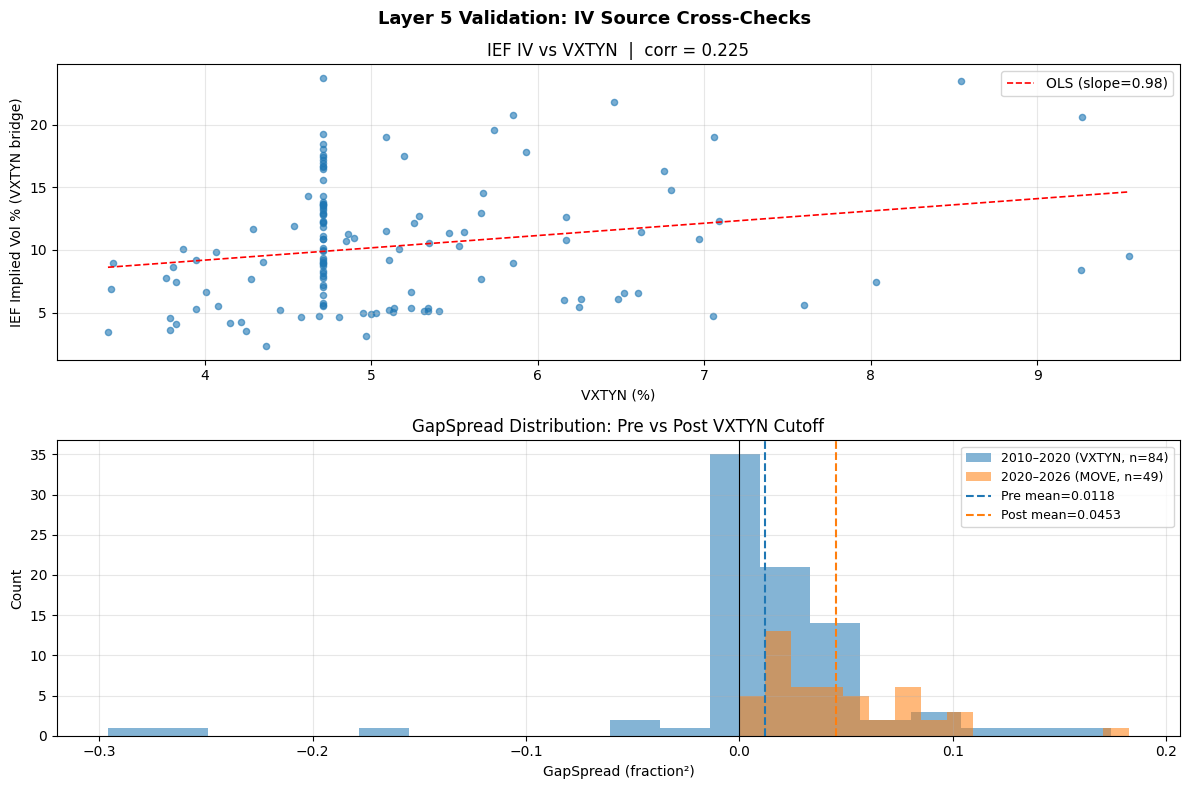

Fig 5 saved


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle("Layer 5 Validation: IV Source Cross-Checks", fontsize=13, fontweight="bold")

# Panel 1: IEF IV vs VXTYN scatter
ax = axes[0]
if not cross_check.empty:
    ax.scatter(cross_check["VXTYN"], cross_check["IEF_iv_pct"],
               alpha=0.6, s=20, color="#1f77b4")
    # OLS line
    coeff = np.polyfit(cross_check["VXTYN"], cross_check["IEF_iv_pct"], 1)
    xx = np.linspace(cross_check["VXTYN"].min(), cross_check["VXTYN"].max(), 100)
    ax.plot(xx, np.polyval(coeff, xx), "r--", lw=1.2, label=f"OLS (slope={coeff[0]:.2f})")
    ax.set_xlabel("VXTYN (%)")
    ax.set_ylabel("IEF Implied Vol % (VXTYN bridge)")
    ax.set_title(f"IEF IV vs VXTYN  |  corr = {corr:.3f}")
    ax.legend()
    ax.grid(alpha=0.3)

# Panel 2: GapSpread distribution
ax = axes[1]
gs_vals = gs_uniq["GapSpread_proxy"].dropna()
pre2020  = gs_uniq[gs_uniq["meeting_date"] <= _VXTYN_END]["GapSpread_proxy"].dropna()
post2020 = gs_uniq[gs_uniq["meeting_date"] >  _VXTYN_END]["GapSpread_proxy"].dropna()
ax.hist(pre2020,  bins=20, alpha=0.55, color="#1f77b4", label=f"2010–2020 (VXTYN, n={len(pre2020)})")
ax.hist(post2020, bins=15, alpha=0.55, color="#ff7f0e", label=f"2020–2026 (MOVE, n={len(post2020)})")
ax.axvline(pre2020.mean(),  color="#1f77b4", ls="--", lw=1.5, label=f"Pre mean={pre2020.mean():.4f}")
ax.axvline(post2020.mean(), color="#ff7f0e", ls="--", lw=1.5, label=f"Post mean={post2020.mean():.4f}")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("GapSpread (fraction²)")
ax.set_ylabel("Count")
ax.set_title("GapSpread Distribution: Pre vs Post VXTYN Cutoff")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(VIZ_DIR / "fig_etf_05_validation.png", dpi=130, bbox_inches="tight")
plt.show()
print("Fig 5 saved")

## Export and Summary

In [14]:
# Export gap curve
output_path = Path("etf_gap_curve.parquet")
gap_df.to_parquet(output_path, index=False)

print(f"Exported: {output_path}  ({len(gap_df)} rows)")
print(f"Columns: {list(gap_df.columns)}")
print(f"\nSource coverage:")
src_counts = gap_df.groupby("source")["meeting_date"].nunique()
print(src_counts.to_string())
print(f"\nGapSpread sign breakdown:")
signs = gs_uniq["spread_direction"].value_counts()
print(signs.to_string())
print(f"\nFull-period GapSpread statistics:")
print(gs_uniq["GapSpread_proxy"].describe().round(6).to_string())
print(f"\nMost recent 5 meetings:")
print(gs_uniq.tail(5)[["meeting_date","GapSpread_proxy","spread_direction"]].to_string(index=False))

Exported: etf_gap_curve.parquet  (665 rows)
Columns: ['meeting_date', 'etf', 'tenor_proxy', 'rv_event_gk_pct', 'rv_event_park_pct', 'rv_event_var', 'rv_event_park_var', 'rv_fwd_1d_var', 'rv_fwd_5d_var', 'rv_fwd_10d_var', 'rv_vol_pct', 'year', 'iv_event_var', 'iv_event_vol_pct', 'iv_percentile', 'source', 'expiry_pre', 'expiry_post', 'window_flag', 'gap', 'has_iv', 'has_rv', 'has_both', 'GapSpread_proxy', 'spread_direction', 'basis_flag']

Source coverage:
source
move_bridge     49
vxtyn_bridge    84

GapSpread sign breakdown:
spread_direction
buy_front_sell_long    110
buy_long_sell_front     23

Full-period GapSpread statistics:
count    133.000000
mean       0.024147
std        0.054921
min       -0.295853
25%        0.003493
50%        0.020301
75%        0.044144
max        0.182468

Most recent 5 meetings:
meeting_date  GapSpread_proxy    spread_direction
  2025-12-10         0.025593 buy_front_sell_long
  2026-01-28         0.015999 buy_front_sell_long
  2026-03-18         0.0407

In [15]:
# Data sources reference
print("\n" + "="*65)
print("DATA SOURCES USED IN THIS NOTEBOOK")
print("="*65)
print("""
  Layer 1  FRED (public API / CSV fallback)
           - Treasury yields: DGS2, DGS5, DGS7, DGS10, DGS20, DGS30
           - Regime: FEDFUNDS, UNRATE, CPIAUCSL, DFF
           - Implied cross-check: VXTYN (2010-2020 only)

  Layer 2  ETF OHLC via yfinance (SHY, IEI, IEF, TLH, TLT)
           - Garman-Klass daily variance → event-day RV strip

  Layer 3a VXTYN bridge (2010-2020)
           - vrp_cache/vrp_panel.parquet (CBOE TYVIX → per-tenor IV)
           - Source tag: 'vxtyn_bridge'

  Layer 3b MOVE bridge (2020-2026)
           - ^MOVE via yfinance (ICE BofA MOVE Index)
           - Conversion: yield_bps = MOVE × ratio, price_vol = bps × dur / 100
           - Calibrated ratios from VXTYN 2010-2020 cross-correlation
           - Source tag: 'move_bridge'

  Optional AlphaVantage HISTORICAL_OPTIONS (ALPHAVANTAGE_API_KEY, premium)
           WRDS/OptionMetrics (WRDS_USERNAME, institutional)
           Manual CSV: etf_implied_manual.csv

  Proxy basis risk: Signal trained on ETF price-vol;
  trade expressed on ZT/ZB Treasury futures (different duration/convexity).
""")


DATA SOURCES USED IN THIS NOTEBOOK

  Layer 1  FRED (public API / CSV fallback)
           - Treasury yields: DGS2, DGS5, DGS7, DGS10, DGS20, DGS30
           - Regime: FEDFUNDS, UNRATE, CPIAUCSL, DFF
           - Implied cross-check: VXTYN (2010-2020 only)

  Layer 2  ETF OHLC via yfinance (SHY, IEI, IEF, TLH, TLT)
           - Garman-Klass daily variance → event-day RV strip

  Layer 3a VXTYN bridge (2010-2020)
           - vrp_cache/vrp_panel.parquet (CBOE TYVIX → per-tenor IV)
           - Source tag: 'vxtyn_bridge'

  Layer 3b MOVE bridge (2020-2026)
           - ^MOVE via yfinance (ICE BofA MOVE Index)
           - Conversion: yield_bps = MOVE × ratio, price_vol = bps × dur / 100
           - Calibrated ratios from VXTYN 2010-2020 cross-correlation
           - Source tag: 'move_bridge'

  Optional AlphaVantage HISTORICAL_OPTIONS (ALPHAVANTAGE_API_KEY, premium)
           WRDS/OptionMetrics (WRDS_USERNAME, institutional)
           Manual CSV: etf_implied_manual.csv

  Proxy bas